# import libraries

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# shift signal [full]

In [33]:
def shift_signal(x,t,beta):
    dt = t[1] - t[0]
    shift_by = round(beta/dt)

    y = np.roll(x, shift_by)

    return y

# shift signal [limitted]

In [34]:

def shift_signal2(x,t,beta):
    dt = t[1] - t[0]
    shift_by = round(beta/dt)

    y = np.roll(x, shift_by)

    if(shift_by > 0):
            y[:shift_by] = 0
    elif(shift_by < 0):
        y[shift_by:] = 0
        
    return y

# reverse signal

In [35]:
def reverse_signal(x,t):
    y = x[::-1]

    return y

# amplitude scale signal

In [36]:
def amp_scale_signal(x,t,alpha):
    y = alpha * x

    return y

# time scale signal [full]
when multiplied, the signal shrinks.    y(t) = sin(5t)  -> high frequency

when divided, the signal expands.       y(t) = sin(t/2) -> low frequency

In [37]:
def scale_signal(x, t, alpha):
    dt = t[1] - t[0]
    n = len(t)
    y = np.zeros(n)

    for i in range(n):
        target_time = alpha * t[i]
        index = round(target_time / dt)
        index = index % n   # wrap instead of going out of bounds

        y[i] = x[index]

    return y

# time scale signal [limitted]

In [38]:
def scale_signal2(x, t, alpha):
    dt = t[1] - t[0]
    n = len(t)
    y = np.zeros(n)

    for i in range(n):
        # We want y[i] = x(alpha * t[i])
        # Find which index in t corresponds to time alpha*t[i]
        target_time = alpha * t[i]
        index = round(target_time / dt)

        if 0 <= index < n:
            y[i] = x[index]
        else:
            y[i] = 0  # out of range, pad with 0

    return y

# sine wave

In [39]:
def sine_signal(t):
    x = np.sin(t)
    return x

## -π to π sine wave 

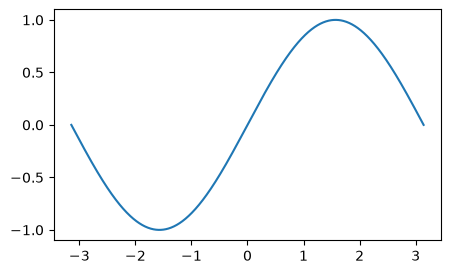

In [40]:
def plot_sine():
    t = np.linspace(-np.pi, np.pi, 1000)
    x = sine_signal(t)

    plt.figure(figsize = (5,3))
    plt.plot(t,x)



    plt.show()

plot_sine()


## formatted

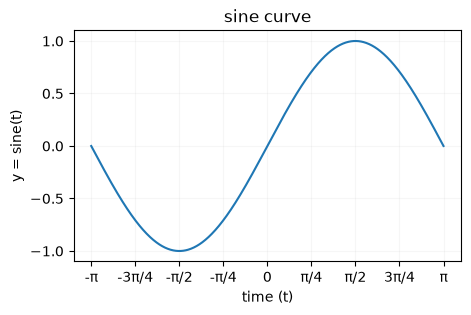

In [41]:
def plot_sine2():
    t = np.linspace(-np.pi, np.pi, 1000)
    x = sine_signal(t)

    plt.figure(figsize = (5,3))
    plt.plot(t,x)

    ticks = np.linspace(-np.pi, np.pi, 9)
    labels = ['-π', '-3π/4', '-π/2','-π/4', '0', 'π/4', 'π/2', '3π/4', 'π']
    plt.xticks(ticks, labels)

    plt.grid(True, alpha = 0.1)
    plt.xlabel('time (t)')
    plt.ylabel('y = sine(t)')
    plt.title('sine curve')

    plt.show()

plot_sine2()

## left shift sine signal by π/2 (full signal)
## $$ sin(t + π/2) $$

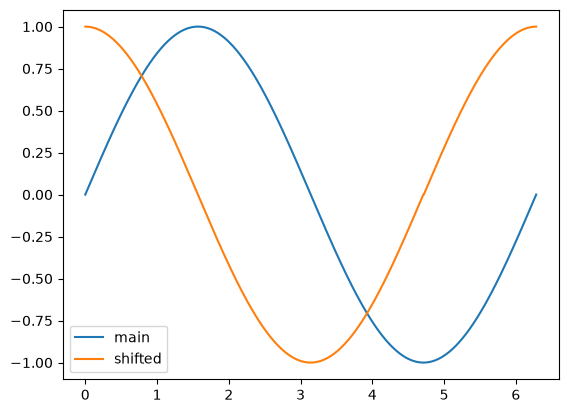

In [42]:
def main1():
    t = np.linspace(0, np.pi * 2, 1000)
    x = sine_signal(t)
    alpha = np.pi / 2

    x_shifted = shift_signal(x,t,-alpha)
    y = x_shifted

    plt.plot(t,x, label = 'main')
    plt.plot(t,y, label = 'shifted')

    plt.legend()
    plt.show()


main1()

## left shift sine signal by π/2 (limitted signal)
## $$ sin(t + π/2) $$

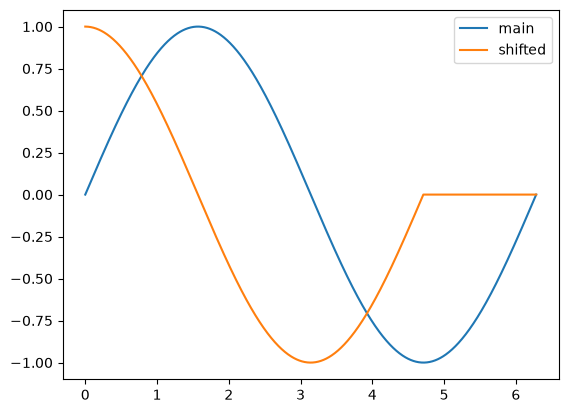

In [43]:
def main1():
    t = np.linspace(0, np.pi * 2, 1000)
    x = sine_signal(t)
    alpha = np.pi / 2

    x_shifted = shift_signal2(x,t,-alpha)  # <--- change 
    y = x_shifted

    plt.plot(t,x, label = 'main')
    plt.plot(t,y, label = 'shifted')

    plt.legend()
    plt.show()


main1()

## practice

### y = 2sin(t - π/2)

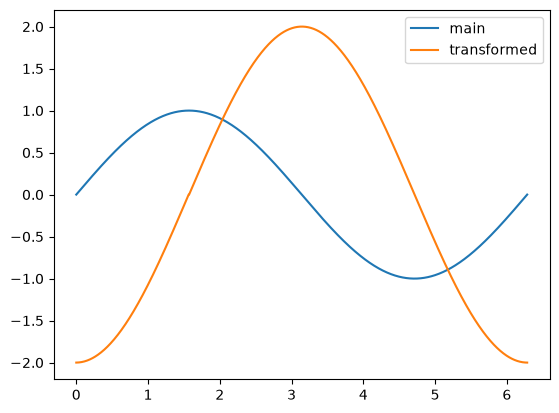

In [44]:
def main2():
    t = np.linspace(0, np.pi * 2, 1000)
    x = sine_signal(t)
    alpha = -np.pi / 2

    x_shifted = shift_signal(x,t, -alpha)
    y = amp_scale_signal(x_shifted,t,2)

    plt.plot(t,x, label = 'main')
    plt.plot(t,y, label = 'transformed')

    plt.legend()
    plt.show()


main2()

### y = 2sin(5t - π/2)

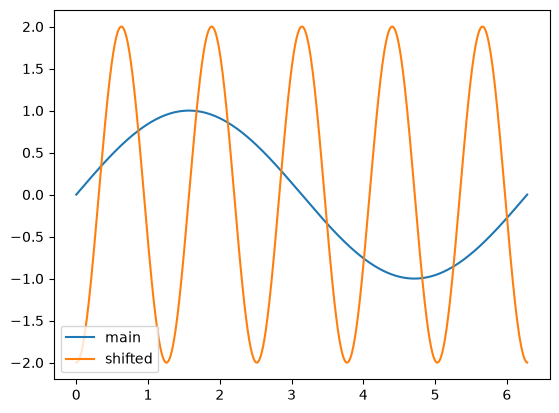

In [45]:
def main3():
    t = np.linspace(0, np.pi * 2, 1000)
    x = sine_signal(t)
    alpha = -np.pi / 2

    x_shifted = shift_signal(x,t, -alpha)
    x_scaled = scale_signal(x_shifted,t,5)
    y = amp_scale_signal(x_scaled,t,2)


    plt.plot(t,x, label = 'main')
    plt.plot(t,y, label = 'shifted')

    plt.legend()
    plt.show()


main3()